In [1]:
import pulp as plp
import pandas as pd
import numpy as np

In [2]:
from docplex.mp.model import Model

## Funciones

In [3]:
# --- FUNCIONES AUXILIARES DE FORMATO ---
def formatear_gams(valor, decimales=4, es_na=False):
    if es_na: return "NA"
    if hasattr(valor, 'constant'):
        valor = valor.constant
    valor = float(valor)
    if valor > 1e19: return "+INF"
    if valor < -1e19: return "-INF"
    if abs(valor) < 1e-7: return "." 
    cadena = f"{valor:.{decimales}f}"
    return cadena.rstrip('0').rstrip('.') if decimales == 5 else cadena

def obtener_valor_seguro(objeto):
    return objeto.constant if hasattr(objeto, 'constant') else float(objeto)

# --- FUNCIÓN PRINCIPAL DE REPORTE AUTOMÁTICO ---
def generar_reporte_gams(mdl):
    """
    Toma cualquier modelo de Docplex, lo resuelve y genera el reporte estilo GAMS automáticamente.
    """
    solucion = mdl.solve()
    
    if not solucion:
        print("El modelo no encontró una solución factible o es ilimitado.")
        return
        
    cplex_inst = mdl.get_engine().get_cplex()
    
    # 1. Extraer elementos dinámicamente (no importa cuántos sean)
    variables = list(mdl.iter_variables())
    restricciones = list(mdl.iter_constraints())
    
    # Extraer sensibilidad usando la API interna
    sa_rhs = cplex_inst.solution.sensitivity.rhs()
    lim_inf_rhs, lim_sup_rhs = [r[0] for r in sa_rhs], [r[1] for r in sa_rhs]
    
    sa_obj = cplex_inst.solution.sensitivity.objective()
    lim_inf_obj, lim_sup_obj = [r[0] for r in sa_obj], [r[1] for r in sa_obj]
    
    # Extraer coeficientes actuales de la Función Objetivo
    expr_obj = mdl.get_objective_expr()
    coefs_actuales = [expr_obj.get_coef(var) if hasattr(expr_obj, 'get_coef') else 0.0 for var in variables]

    # 2. IMPRESIÓN DEL REPORTE
    print("\n--- Objective ranging... --- (Intervalos de recursos)")
    print(f"{'EQUATION NAME':<18} {'LOWER':>10} {'CURRENT':>10} {'UPPER':>10}")
    print("-" * 52)
    print(f"{'obj':<18} {'-INF':>10} {'NA':>10} {'+INF':>10}")
    
    for i, ct in enumerate(restricciones):
        nombre_ct = ct.name if ct.name else f"eq{i+1}"
        print(f"{nombre_ct:<18} {formatear_gams(lim_inf_rhs[i], 5):>10} "
              f"{formatear_gams(ct.rhs, 5):>10} {formatear_gams(lim_sup_rhs[i], 5):>10}")
        
    print("\n--- Variable ranging... --- (Intervalos para coeficientes F.O.)")
    print(f"{'VARIABLE NAME':<18} {'LOWER':>10} {'CURRENT':>10} {'UPPER':>10}")
    print("-" * 52)
    
    for i, var in enumerate(variables):
        nombre_var = var.name if var.name else f"var{i+1}"
        print(f"{nombre_var:<18} {formatear_gams(lim_inf_obj[i], 5):>10} "
              f"{formatear_gams(coefs_actuales[i], 5):>10} {formatear_gams(lim_sup_obj[i], 5):>10}")
    print(f"{'z':<18} {'-INF':>10} {'NA':>10} {'+INF':>10}")

    print(f"\nOptimal solution found\nObjective: {solucion.objective_value:.6f}\n")

    print(f"{'':<18} {'LOWER':>10} {'LEVEL':>10} {'UPPER':>10} {'MARGINAL':>10}")
    print("-" * 62)
    
    # Sección de Restricciones
    print(f"---- EQU {'obj':<9} {'-INF':>10} {'.':>10} {'.':>10} {'1.0000':>10}")
    for ct in restricciones:
        nombre_ct = ct.name[:9] if ct.name else f"eq{ct.index}"
        marginal   = formatear_gams(ct.dual_value)
        
        # Ajuste dinámico de los límites LOWER y UPPER según el tipo de restricción (<=, >=, ==)
        if ct.sense.name == 'GE': # >=
            lim_inf = formatear_gams(ct.rhs)
            lim_sup = "+INF"
            nivel_uso = formatear_gams(obtener_valor_seguro(ct.rhs) + ct.slack_value)
        elif ct.sense.name == 'EQ': # ==
            lim_inf = formatear_gams(ct.rhs)
            lim_sup = formatear_gams(ct.rhs)
            nivel_uso = formatear_gams(ct.rhs)
        else: # <= (Por defecto)
            lim_inf = "-INF"
            lim_sup = formatear_gams(ct.rhs)
            nivel_uso = formatear_gams(obtener_valor_seguro(ct.rhs) - ct.slack_value)
            
        print(f"---- EQU {nombre_ct:<9} {lim_inf:>10} {nivel_uso:>10} {lim_sup:>10} {marginal:>10}")

    print("\n")
    print(f"{'':<18} {'LOWER':>10} {'LEVEL':>10} {'UPPER':>10} {'MARGINAL':>10}")
    print("-" * 62)
    
    # Sección de Variables
    for var in variables:
        nombre_var = var.name[:9] if var.name else f"var{var.index}"
        limite_inf = formatear_gams(var.lb)
        limite_sup = formatear_gams(var.ub)
        nivel      = formatear_gams(var.solution_value)
        marginal   = formatear_gams(var.reduced_cost)
        print(f"---- VAR {nombre_var:<9} {limite_inf:>10} {nivel:>10} {limite_sup:>10} {marginal:>10}")
        
    print(f"---- VAR {'z':<9} {'-INF':>10} {formatear_gams(solucion.objective_value):>10} {'+INF':>10} {'.':>10}")

## Ejemplo 1

In [14]:
# 1. Creas tu modelo vacío
modelo = Model(name='Ejemplo1')

# 2. Defines las variables
x1 = modelo.continuous_var(lb=0, name='x1')
x2 = modelo.continuous_var(lb=0, name='x2')

# 3. Agregas la Función Objetivo
modelo.maximize(45 * x1 + 20 * x2)

# 4. Agregas las Restricciones
modelo.add_constraint(2 * x1 + x2 <= 8, ctname='r1')
modelo.add_constraint(x1 + 3 * x2 <= 8, ctname='r2')

# 5. Llamas a la funcion de reporte
generar_reporte_gams(modelo)


--- Objective ranging... --- (Intervalos de recursos)
EQUATION NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
obj                      -INF         NA       +INF
r1                          .          8         16
r2                          4          8       +INF

--- Variable ranging... --- (Intervalos para coeficientes F.O.)
VARIABLE NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
x1                         40         45       +INF
x2                       -INF         20       22.5
z                        -INF         NA       +INF

Optimal solution found
Objective: 180.000000

                        LOWER      LEVEL      UPPER   MARGINAL
--------------------------------------------------------------
---- EQU obj             -INF          .          .     1.0000
---- EQU r1              -INF     8.0000     8.0000    22.5000
---- EQU r2              -INF     4.0000     8.0000        

## Ejemplo 2

In [5]:
# 1. Creas tu modelo vacío
modelo = Model(name='Ejemplo2')

# 2. Defines las variables
x1 = modelo.continuous_var(lb=0, name='x1')
x2 = modelo.continuous_var(lb=0, name='x2')

# 3. Agregas la Función Objetivo
modelo.maximize(2 * x1 + 3 * x2)

# 4. Agregas las Restricciones
modelo.add_constraint(2 * x1 + 3 * x2 <= 8, ctname='r1')
modelo.add_constraint(2 * x1 + 6 * x2 <= 18, ctname='r2')

# 5. Llamas a la funcion de reporte
generar_reporte_gams(modelo)


--- Objective ranging... --- (Intervalos de recursos)
EQUATION NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
obj                      -INF         NA       +INF
r1                          .          8         18
r2                          8         18       +INF

--- Variable ranging... --- (Intervalos para coeficientes F.O.)
VARIABLE NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
x1                          2          2       +INF
x2                       -INF          3          3
z                        -INF         NA       +INF

Optimal solution found
Objective: 8.000000

                        LOWER      LEVEL      UPPER   MARGINAL
--------------------------------------------------------------
---- EQU obj             -INF          .          .     1.0000
---- EQU r1              -INF     8.0000     8.0000     1.0000
---- EQU r2              -INF     8.0000    18.0000          

## Ejemplo 3

In [6]:
# 1. Creas tu modelo vacío
modelo = Model(name='Ejemplo3')

# 2. Defines las variables
x1 = modelo.continuous_var(lb=0, name='x1')
x2 = modelo.continuous_var(lb=0, name='x2')
x3 = modelo.continuous_var(lb=0, name='x3')

# 3. Agregas la Función Objetivo
modelo.maximize(150 * x1 + 200 * x2 - 10 * x3)

# 4. Agregas las Restricciones
modelo.add_constraint(x1 + x2 <= 45, ctname='r1')
modelo.add_constraint(6 * x1 + 10 * x2 - x3 <= 0, ctname='r2')
modelo.add_constraint(x3 <= 350, ctname='r3')
modelo.add_constraint(5 * x1 <= 140, ctname='r4')
modelo.add_constraint(4 * x2 <= 120, ctname='r5')

# 5. Llamas a la funcion de reporte
generar_reporte_gams(modelo)


--- Objective ranging... --- (Intervalos de recursos)
EQUATION NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
obj                      -INF         NA       +INF
r1                   38.33333         45       46.2
r2                        -12          .         40
r3                        338        350        390
r4                        125        140       +INF
r5                         80        120       +INF

--- Variable ranging... --- (Intervalos para coeficientes F.O.)
VARIABLE NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
x1                        120        150        160
x2                        190        200        250
x3                      -12.5        -10       +INF
z                        -INF         NA       +INF

Optimal solution found
Objective: 4250.000000

                        LOWER      LEVEL      UPPER   MARGINAL
---------------------------------------

1) Si solo se dispusieran de 40 acres de tierra, ¿cuál sería la utilidad del agricultor?

   $b_1 = 45 =>  \bar{b_1} = 40$

   $\bar{z} = 4250 - 5(75) = 3875$
    
2) ¿Cuál es el incremento permisible y el decremento permisible para la cantidad de trigo que es posible vender?
¿Y cuál es el incremento y decremento permisibles para el maíz?

    Puede incrementar infinito, y decrementar 15 en el trigo y 40 en el maíz

   
3) Si solo 130 bushels de trigo pudieran venderse entonces, ¿cambiaría la solución del problema?

   No, ya que está dentro del intervalo del trigo

   
6) ¿Cuál es lo más que el agricultor debe pagar por una hora adicional de mano de obra?

   2.5 por hora

   
8) ¿Cuál es lo más que el agricultor debe pagar por un acre adicional de tierra?

    75 

## Actividad

In [7]:
# 1. Creas tu modelo vacío
modelo = Model(name='Actividad1')

# 2. Defines las variables
x1 = modelo.continuous_var(lb=0, name='x1')
x2 = modelo.continuous_var(lb=0, name='x2')
x3 = modelo.continuous_var(lb=0, name='x3')

# 3. Agregas la Función Objetivo
modelo.maximize(300 * x1 + 400 * x2 - 50 * x3)

# 4. Agregas las Restricciones
modelo.add_constraint(0.8 * x1 + x2  <= x3, ctname='r1')
modelo.add_constraint(x3 <= 98, ctname='r2')
modelo.add_constraint(0.6 * x1 + 0.7 * x2 <= 73, ctname='r3')
modelo.add_constraint(2 * x1 + 3 * x2 <= 260, ctname='r4')
modelo.add_constraint(x1 >= 88, ctname='r5')
modelo.add_constraint(x2 >= 26, ctname='r6')

# 5. Llamas a la funcion de reporte
generar_reporte_gams(modelo)


--- Objective ranging... --- (Intervalos de recursos)
EQUATION NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
obj                      -INF         NA       +INF
r1                       -1.6         98        0.4
r2                       96.4         98       98.4
r3                      72.12         73       +INF
r4                      258.8        260       +INF
r5                         85         88         90
r6                       -INF         26       27.6

--- Variable ranging... --- (Intervalos para coeficientes F.O.)
VARIABLE NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
x1                       -INF        300        320
x2                        375        400       +INF
x3                       -400        -50       +INF
z                        -INF         NA       +INF

Optimal solution found
Objective: 32540.000000

                        LOWER      LEVEL      UPP

## Ejemplo 5

In [18]:
# 1. Creas tu modelo vacío
modelo = Model(name='Elektra')

# 2. Defines las variables
x1 = modelo.continuous_var(lb=0, name='x1')
x2 = modelo.continuous_var(lb=0, name='x2')
x3 = modelo.continuous_var(lb=0, name='x3')
x4 = modelo.continuous_var(lb=0, name='x4')

# 3. Agregas la Función Objetivo
modelo.maximize(60 * x1 + 40 * x2 + 25 * x3 + 38 * x4)

# 4. Agregas las Restricciones
modelo.add_constraint(x1 <= 500, ctname='r1')
modelo.add_constraint(x2 <= 500, ctname='r2')
modelo.add_constraint(x3 <= 800, ctname='r3')
modelo.add_constraint(x4 <= 750, ctname='r4')
modelo.add_constraint(8 * x1 + 5 * x2 + 4 * x3 + 6 * x4 <= 8000, ctname='r5')

# 5. Llamas a la funcion de reporte
generar_reporte_gams(modelo)


--- Objective ranging... --- (Intervalos de recursos)
EQUATION NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
obj                      -INF         NA       +INF
r1                        125        500      687.5
r2                          .        500        800
r3                          .        800       +INF
r4                        250        750       +INF
r5                       6500       8000      11000

--- Variable ranging... --- (Intervalos para coeficientes F.O.)
VARIABLE NAME           LOWER    CURRENT      UPPER
----------------------------------------------------
x1                   50.66667         60       +INF
x2                   31.66667         40       +INF
x3                       -INF         25   25.33333
x4                       37.5         38         45
z                        -INF         NA       +INF

Optimal solution found
Objective: 59500.000000

                        LOWER      LEVEL      UPP

a) Determine la combinación óptima de producción diaria.

b) El programa de producción actual satisface las necesidades de Electra. Sin embargo, debido a la competencia,
es posible que Electra tenga que reducir el precio del motor tipo 2. ¿Cuál es la reducción máxima que puede
efectuarse sin que cambie el programa de producción actual?

c) Electra decidió reducir 25% solamente el precio del motor tipo 3. Aplique el análisis de sensibilidad para
determinar si la solución óptima no cambia. ¿Qué sucede si ahora reduce el motro tipo 1?

d) Actualmente el motor tipo 4 ya no se produce. ¿Qué tanto debe incrementarse su precio para incluirlo en el
programa de producción?

## Ejemplo 6

Una fábrica produce dos tipos de radios. La compañía cuenta con dos trabajadores para producir los tipos de radios. El trabajador 1 está dispuesto a laborar 40 horas a la semana y recibe 5 dólares por hora, mientras que el trabajador 2 puede trabajar hasta 50 horas por semana por 6 dólares la hora. El precio y los recursos requeridos para elaborar cada tipo de radio se proporcionan en la tabla:

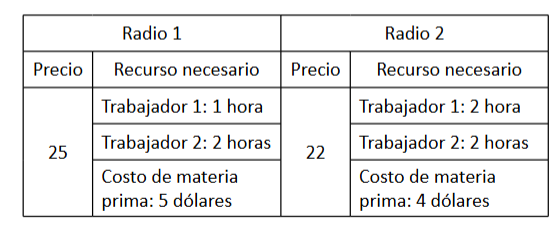

a) Formule un problema de programación lineal y resuélvalo.

b) Interprete la solución obtenida.

c) ¿Qué tanto debe cambiar el coeficiente de la función objetivo para que el radio 2 se produzca?

d) Interprete el costo reducido de cada una de las variables de decisión.

In [19]:
# 1. Creas tu modelo vacío
modelo = Model(name='Radios')

# 2. Defines las variables
x11 = modelo.continuous_var(lb=0, name='x11')
x12 = modelo.continuous_var(lb=0, name='x12')
x21 = modelo.continuous_var(lb=0, name='x21')
x22 = modelo.continuous_var(lb=0, name='x22')

# 3. Agregas la Función Objetivo
modelo.maximize(25 * (x11 + x12) + 22 * (x21 + x22) - 5 * (x11 + x12) -4 * (x21 + x22) - 5 * (x11 +  2 * x21) - 6 * (2 * x12 + 2 * x22))

# 4. Agregas las Restricciones
modelo.add_constraint(x11 + 2 * x21 <= 40, ctname='r1')
modelo.add_constraint(2 *  x21 + 2 * x22 <= 50, ctname='r2')

# 5. Llamas a la funcion de reporte
generar_reporte_gams(modelo)

El modelo no encontró una solución factible o es ilimitado.
